In [1]:
# [setup]
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
from datetime import date

plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

ACCOUNTING_DATE = pd.Timestamp('2026-12-15')
PLOT_START = pd.Timestamp('2025-10-01')
PLOT_END = pd.Timestamp('2027-01-01')

COLORS = {
    '02-27 (pre-shutdown)': '#2196F3',
    '03-23 (post-shutdown)': '#F44336',
    'fake-iran': '#4CAF50',
}

print('Setup complete.')

Setup complete.


In [3]:
!pwd

/Users/brendanwells/work/mozaic-daily


In [4]:
# [load-data]
# File paths
DESKTOP_0227 = 'april/02-27_mw_count/mozaic_daily_forecast.2026-02-27.ld-D.parquet'
DESKTOP_0323 = 'april/03-23_mw_count/mozaic_daily_forecast.2026-03-23.ld-D.parquet'
MOBILE_0227 = 'april/02_27_m_mw_count/mozaic_daily_forecast.2026-02-27.gm-D.parquet'
MOBILE_0323 = 'april/03_23_m_mw_count/mozaic_daily_forecast.2026-03-23.gm-D.parquet'
FAKE_IRAN = 'fake-iran/03-27/mozaic_daily_forecast.2026-03-28.parquet'


def load_world_dau(path, data_source, segment_filter, app_filter=None):
    """Load world-level DAU from a forecast parquet file.
    
    Filters to country='ALL' and the appropriate segment/app aggregation row.
    Returns a DataFrame with columns: target_date, dau, data_type.
    """
    df = pd.read_parquet(path)
    mask = (df['country'] == 'ALL') & (df['data_source'] == data_source)
    if segment_filter is not None:
        mask = mask & (df['segment'] == segment_filter)
    if app_filter is not None:
        mask = mask & (df['app_name'] == app_filter)
    result = df.loc[mask, ['target_date', 'dau', 'data_type']].copy()
    result['target_date'] = pd.to_datetime(result['target_date'])
    result = result.sort_values('target_date').reset_index(drop=True)
    assert len(result) > 0, f'No rows matched for {path} / {data_source}'
    return result


# Desktop: legacy_desktop, segment={"os": "ALL"}, app_name=desktop
desktop_0227 = load_world_dau(DESKTOP_0227, 'legacy_desktop', '{"os": "ALL"}')
desktop_0323 = load_world_dau(DESKTOP_0323, 'legacy_desktop', '{"os": "ALL"}')
desktop_fake = load_world_dau(FAKE_IRAN, 'legacy_desktop', '{"os": "ALL"}')

# Mobile: glean_mobile, app_name='ALL MOBILE', segment={}
mobile_0227 = load_world_dau(MOBILE_0227, 'glean_mobile', '{}', app_filter='ALL MOBILE')
mobile_0323 = load_world_dau(MOBILE_0323, 'glean_mobile', '{}', app_filter='ALL MOBILE')
mobile_fake = load_world_dau(FAKE_IRAN, 'glean_mobile', '{}', app_filter='ALL MOBILE')

print(f'Desktop 02-27: {len(desktop_0227)} rows, {desktop_0227["target_date"].min().date()} to {desktop_0227["target_date"].max().date()}')
print(f'Desktop 03-23: {len(desktop_0323)} rows, {desktop_0323["target_date"].min().date()} to {desktop_0323["target_date"].max().date()}')
print(f'Desktop fake:  {len(desktop_fake)} rows, {desktop_fake["target_date"].min().date()} to {desktop_fake["target_date"].max().date()}')
print(f'Mobile 02-27:  {len(mobile_0227)} rows, {mobile_0227["target_date"].min().date()} to {mobile_0227["target_date"].max().date()}')
print(f'Mobile 03-23:  {len(mobile_0323)} rows, {mobile_0323["target_date"].min().date()} to {mobile_0323["target_date"].max().date()}')
print(f'Mobile fake:   {len(mobile_fake)} rows, {mobile_fake["target_date"].min().date()} to {mobile_fake["target_date"].max().date()}')

Desktop 02-27: 2922 rows, 2020-01-01 to 2027-12-31
Desktop 03-23: 2922 rows, 2020-01-01 to 2027-12-31
Desktop fake:  2922 rows, 2020-01-01 to 2027-12-31
Mobile 02-27:  2557 rows, 2020-12-31 to 2027-12-31
Mobile 03-23:  2557 rows, 2020-12-31 to 2027-12-31
Mobile fake:   2557 rows, 2020-12-31 to 2027-12-31


In [5]:
# [helpers]
def add_ma28(df):
    """Add a 28-day moving average column to a DAU dataframe."""
    df = df.copy()
    df = df.sort_values('target_date')
    df['dau_ma28'] = df['dau'].rolling(28, min_periods=28).mean()
    return df


def trim_to_range(df, start=PLOT_START, end=PLOT_END):
    """Filter dataframe to the plot date range."""
    return df[(df['target_date'] >= start) & (df['target_date'] <= end)].copy()


def format_millions(x, pos):
    """Formatter for y-axis: show values in millions."""
    return f'{x/1e6:.1f}M'


def add_accounting_date_line(ax):
    """Add a vertical line at the Dec 15 accounting date."""
    ax.axvline(ACCOUNTING_DATE, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(ACCOUNTING_DATE, ax.get_ylim()[1], ' Dec 15', 
            va='top', ha='left', fontsize=9, alpha=0.7)


def add_forecast_boundary(ax, forecast_start):
    """Add a subtle vertical line where training ends and forecast begins."""
    ax.axvline(forecast_start, color='gray', linestyle=':', alpha=0.4, linewidth=1)


def plot_three_way(datasets, title, ylabel='DAU'):
    """Plot raw + MA28 three-way comparison.
    
    datasets: dict of {label: dataframe}
    """
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    
    # Raw
    ax = axes[0]
    for label, df in datasets.items():
        df_plot = trim_to_range(df)
        ax.plot(df_plot['target_date'], df_plot['dau'], 
                label=label, color=COLORS[label], alpha=0.7, linewidth=0.8)
    ax.set_title(f'{title} — Raw DAU')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_millions))
    ax.legend(loc='upper right')
    add_accounting_date_line(ax)
    
    # MA28
    ax = axes[1]
    for label, df in datasets.items():
        df_ma = add_ma28(df)
        df_plot = trim_to_range(df_ma)
        ax.plot(df_plot['target_date'], df_plot['dau_ma28'], 
                label=label, color=COLORS[label], alpha=0.9, linewidth=1.5)
    ax.set_title(f'{title} — 28-Day Moving Average')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_millions))
    ax.legend(loc='upper right')
    add_accounting_date_line(ax)
    
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


print('Helpers defined.')

Helpers defined.


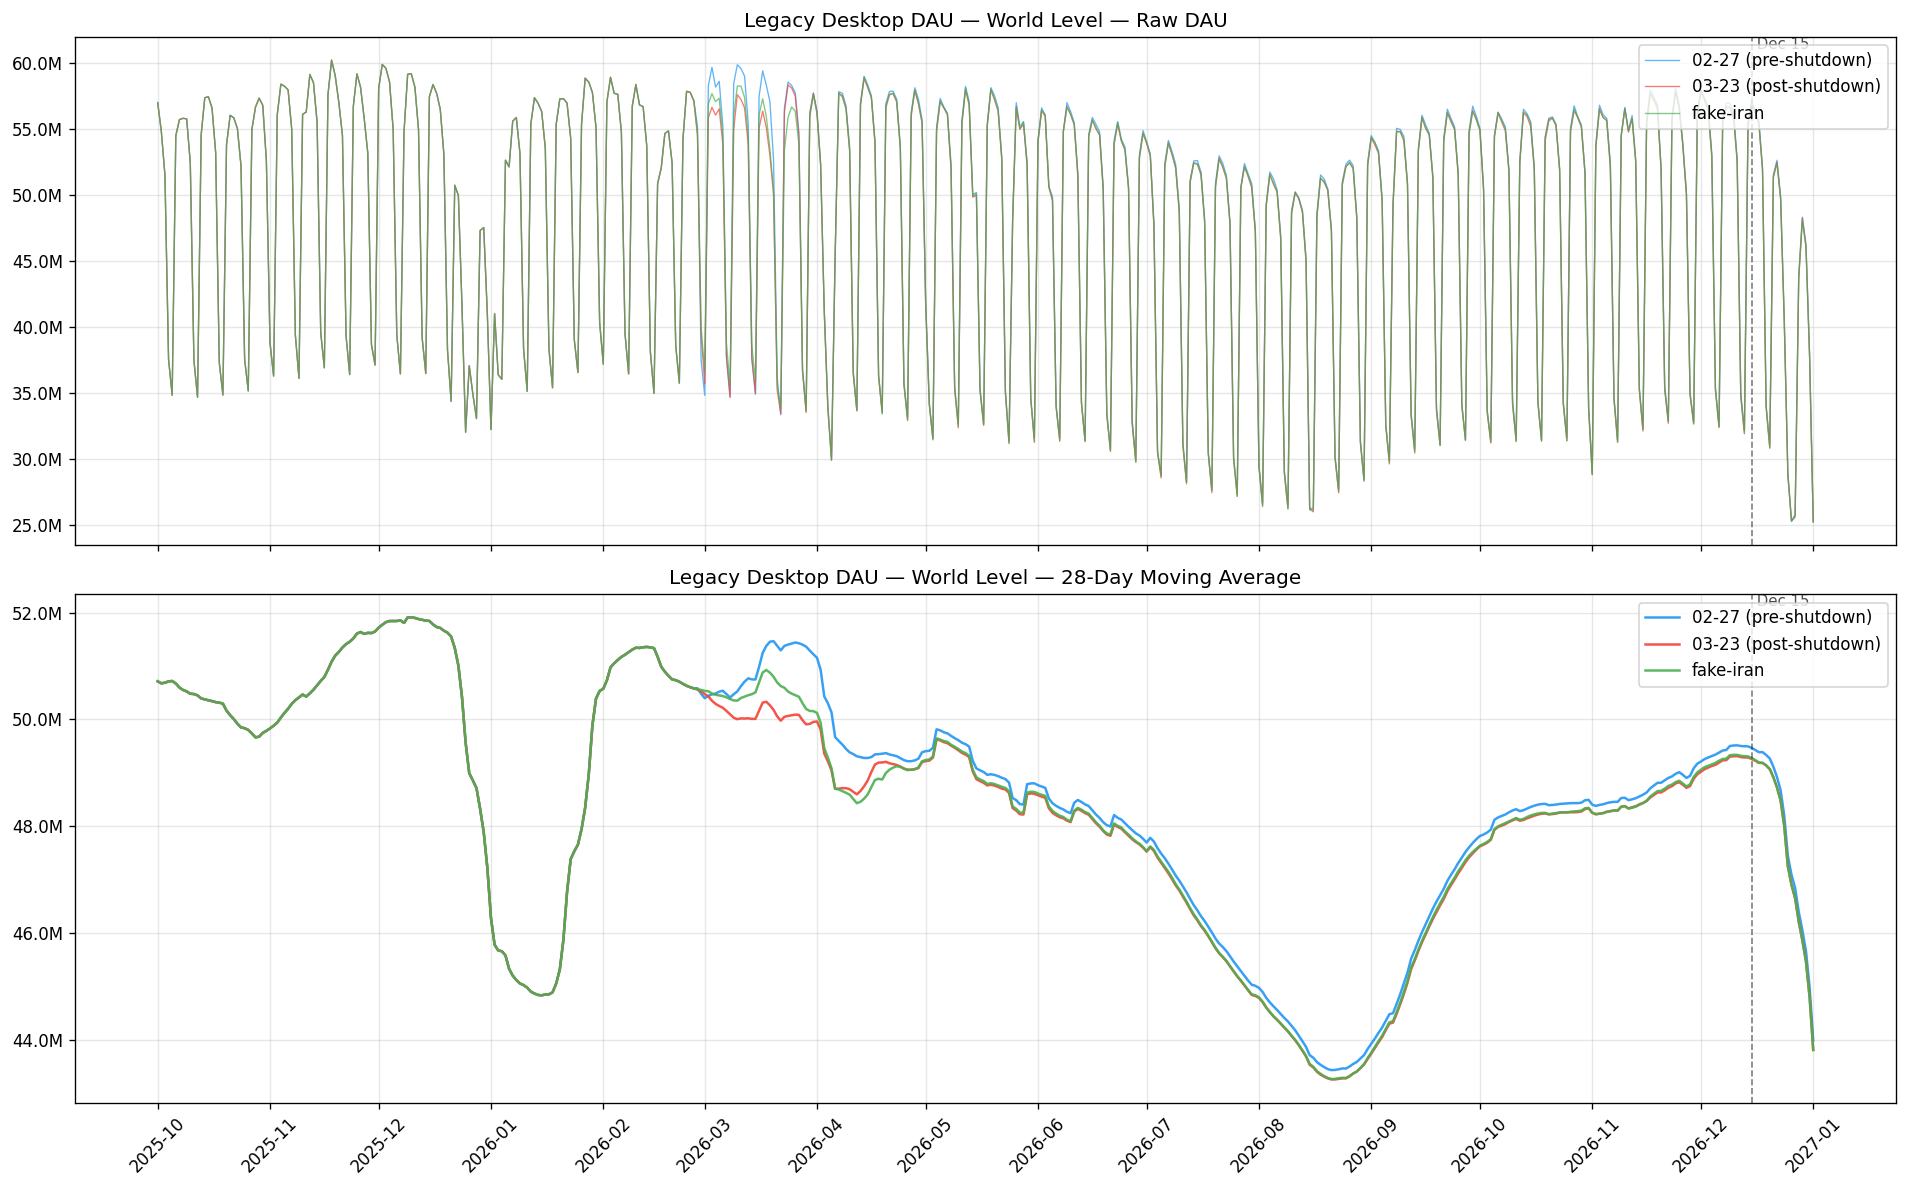

In [6]:
# [desktop-comparison]
plot_three_way(
    {
        '02-27 (pre-shutdown)': desktop_0227,
        '03-23 (post-shutdown)': desktop_0323,
        'fake-iran': desktop_fake,
    },
    title='Legacy Desktop DAU — World Level'
)

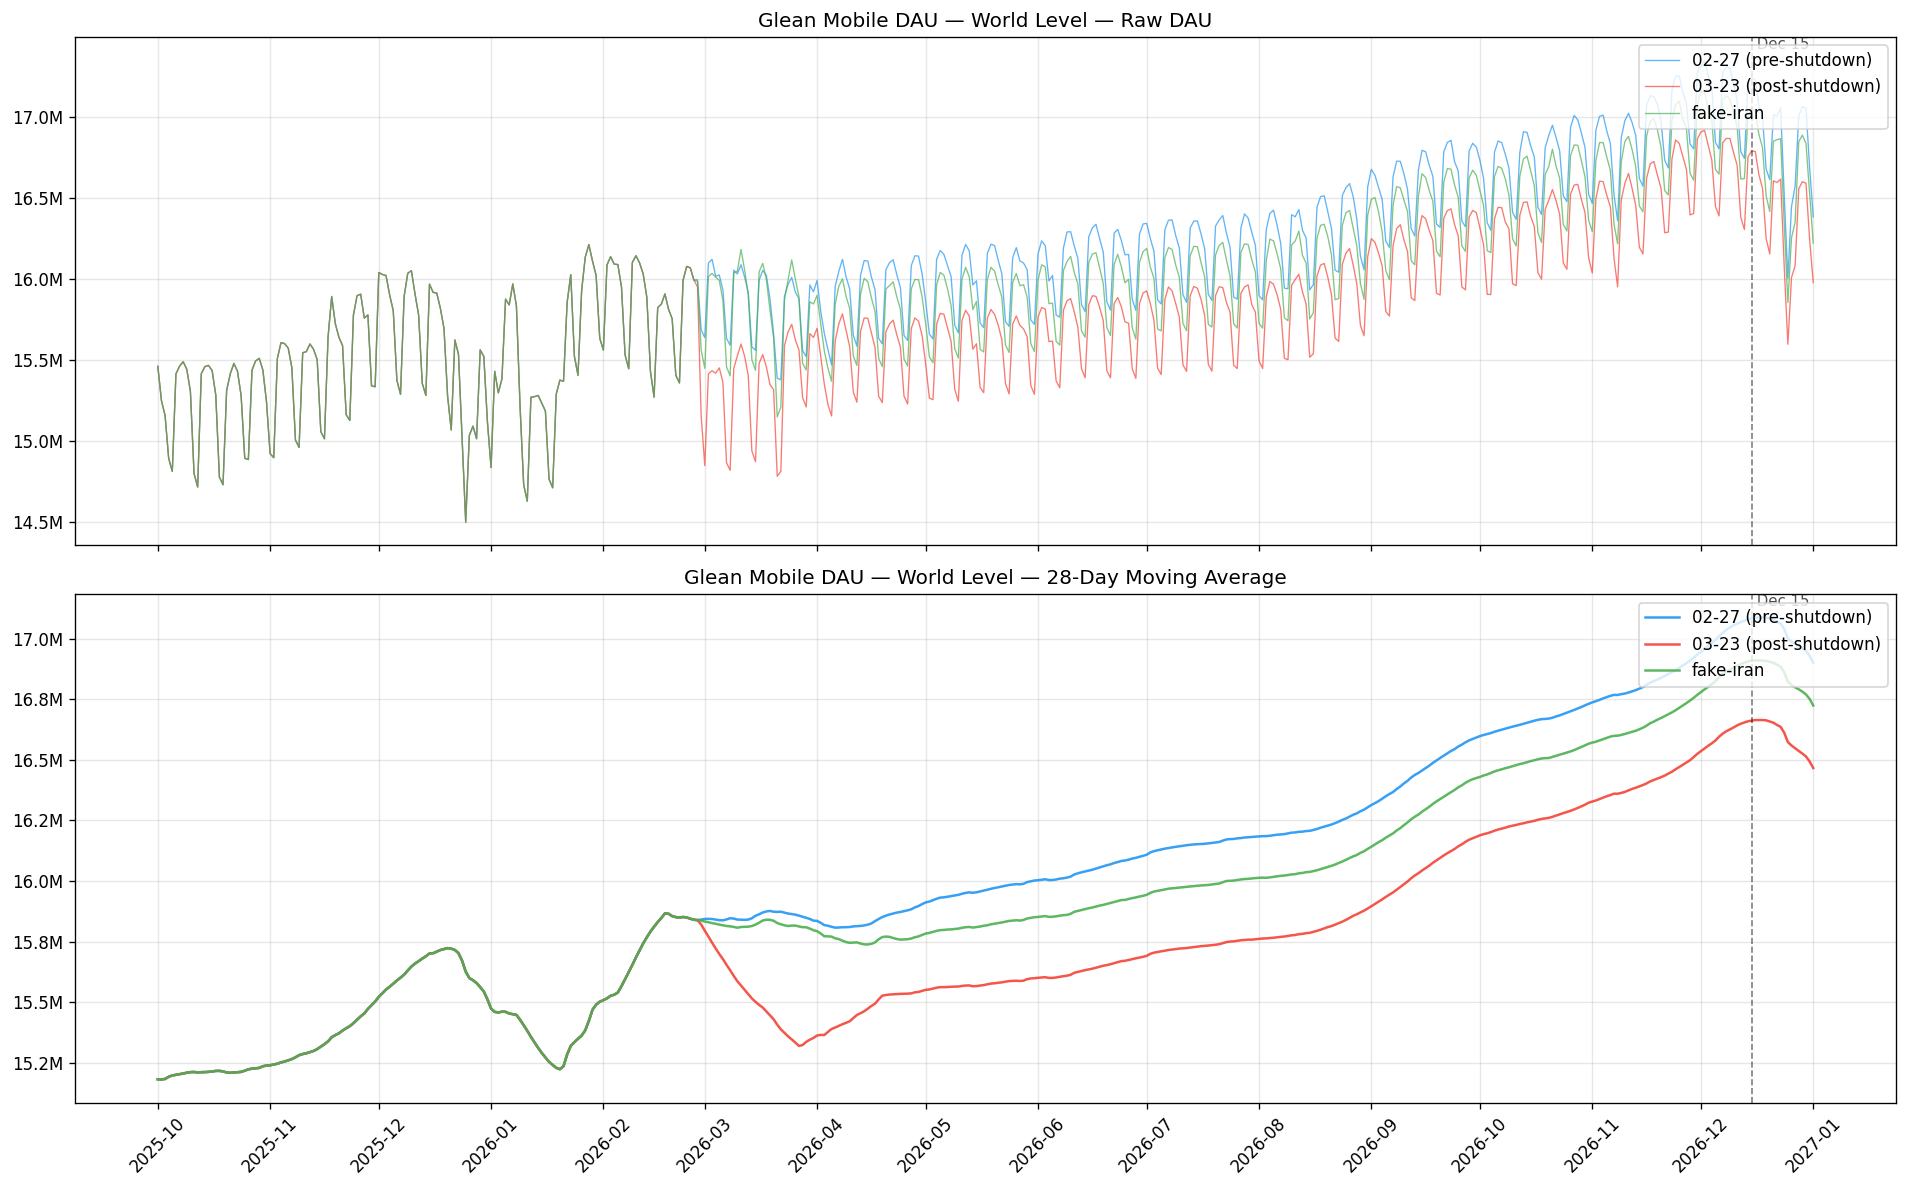

In [7]:
# [mobile-comparison]
plot_three_way(
    {
        '02-27 (pre-shutdown)': mobile_0227,
        '03-23 (post-shutdown)': mobile_0323,
        'fake-iran': mobile_fake,
    },
    title='Glean Mobile DAU — World Level'
)

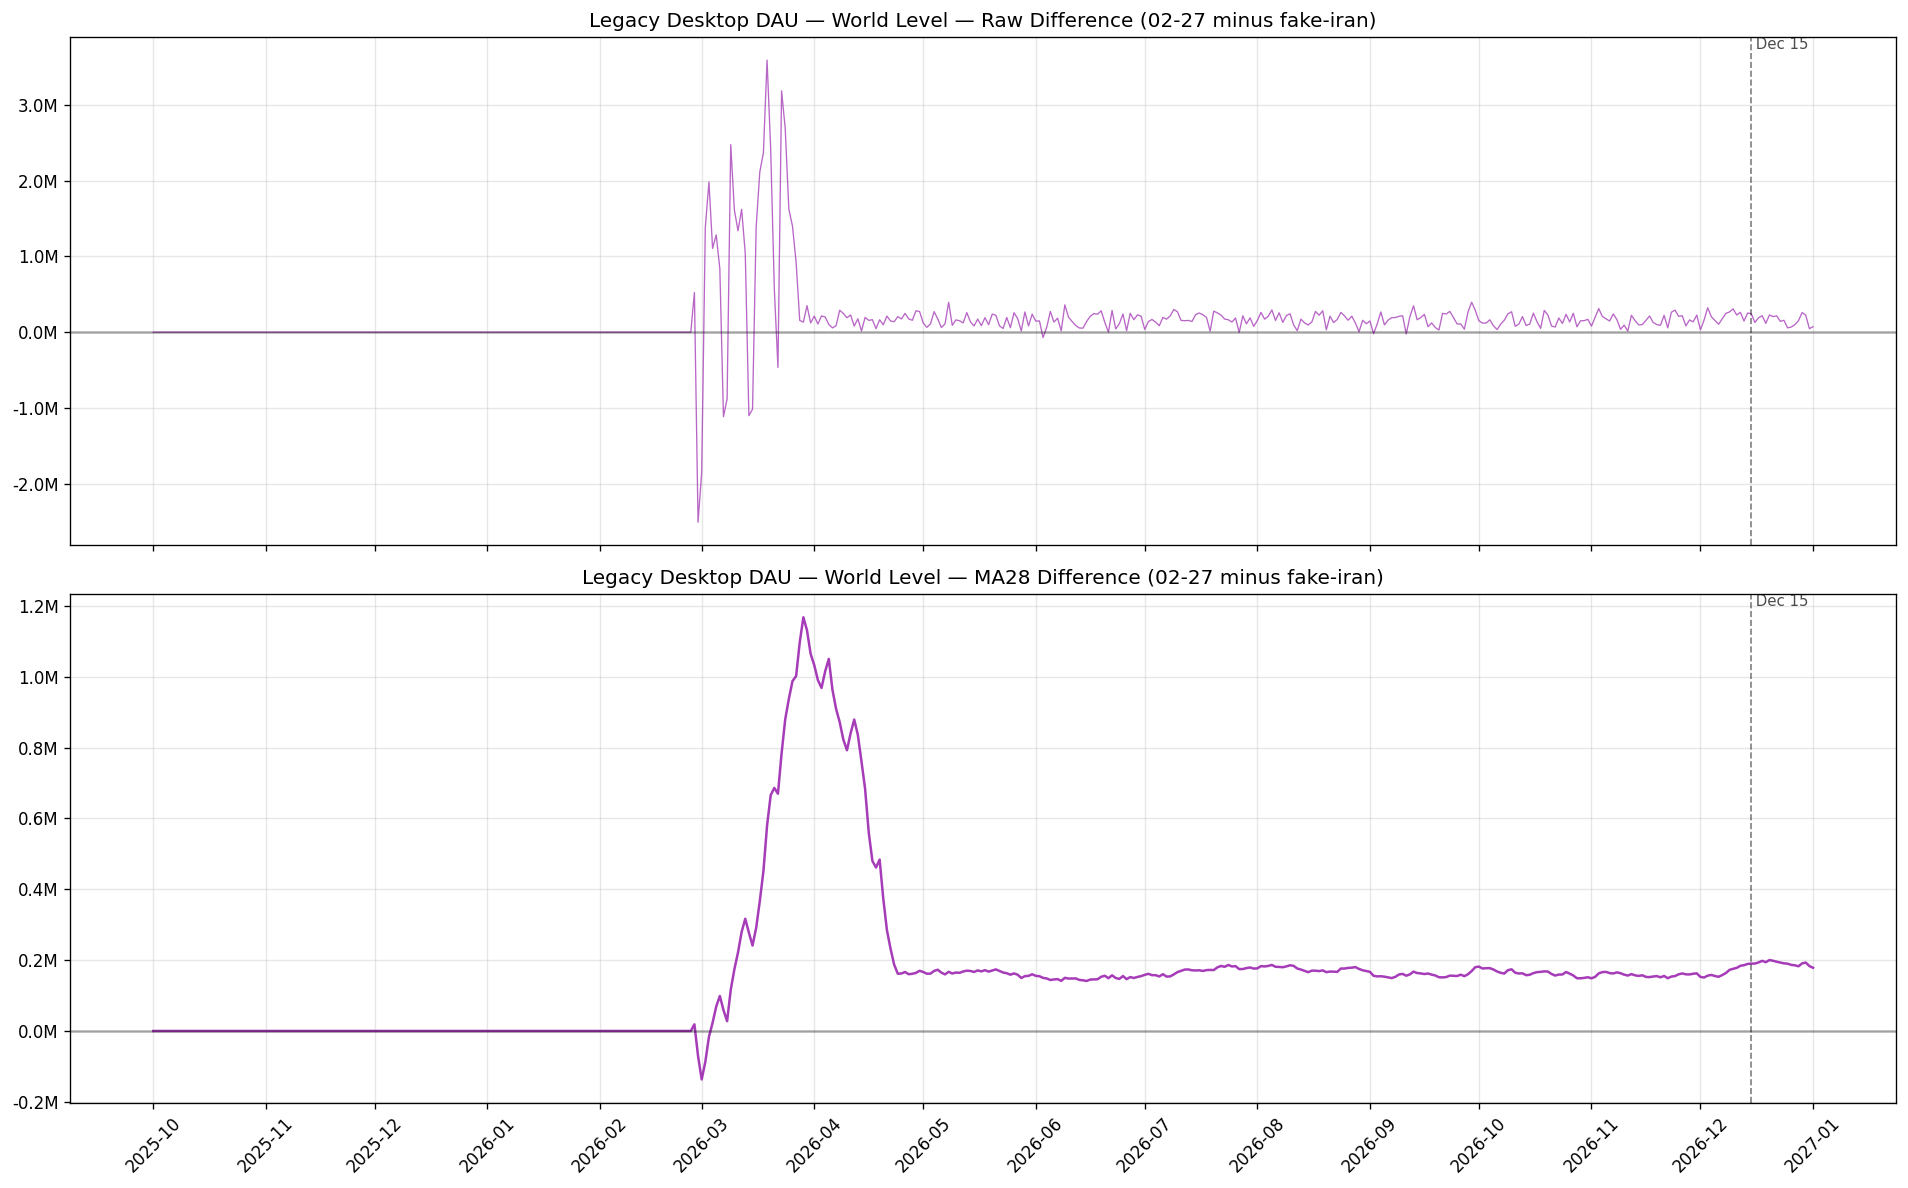

In [8]:
# [desktop-diff-0227-vs-fake]
def plot_difference(base_df, compare_df, title, base_label='02-27', compare_label='fake-iran'):
    """Plot the difference (base - compare) for both raw and MA28.
    
    Positive values mean the base forecast is higher.
    """
    base_ma = add_ma28(base_df)
    compare_ma = add_ma28(compare_df)
    
    # Merge on target_date (inner join — only overlapping dates)
    merged_raw = base_df.merge(compare_df[['target_date', 'dau']], 
                                on='target_date', suffixes=('_base', '_compare'))
    merged_raw['diff'] = merged_raw['dau_base'] - merged_raw['dau_compare']
    
    merged_ma = base_ma.merge(compare_ma[['target_date', 'dau_ma28']], 
                              on='target_date', suffixes=('_base', '_compare'))
    merged_ma['diff'] = merged_ma['dau_ma28_base'] - merged_ma['dau_ma28_compare']
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    
    # Raw difference
    ax = axes[0]
    df_plot = trim_to_range(merged_raw)
    ax.plot(df_plot['target_date'], df_plot['diff'], color='#9C27B0', alpha=0.7, linewidth=0.8)
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_title(f'{title} — Raw Difference ({base_label} minus {compare_label})')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_millions))
    add_accounting_date_line(ax)
    
    # MA28 difference
    ax = axes[1]
    df_plot = trim_to_range(merged_ma)
    ax.plot(df_plot['target_date'], df_plot['diff'], color='#9C27B0', alpha=0.9, linewidth=1.5)
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_title(f'{title} — MA28 Difference ({base_label} minus {compare_label})')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_millions))
    add_accounting_date_line(ax)
    
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_difference(desktop_0227, desktop_fake,
                title='Legacy Desktop DAU — World Level')

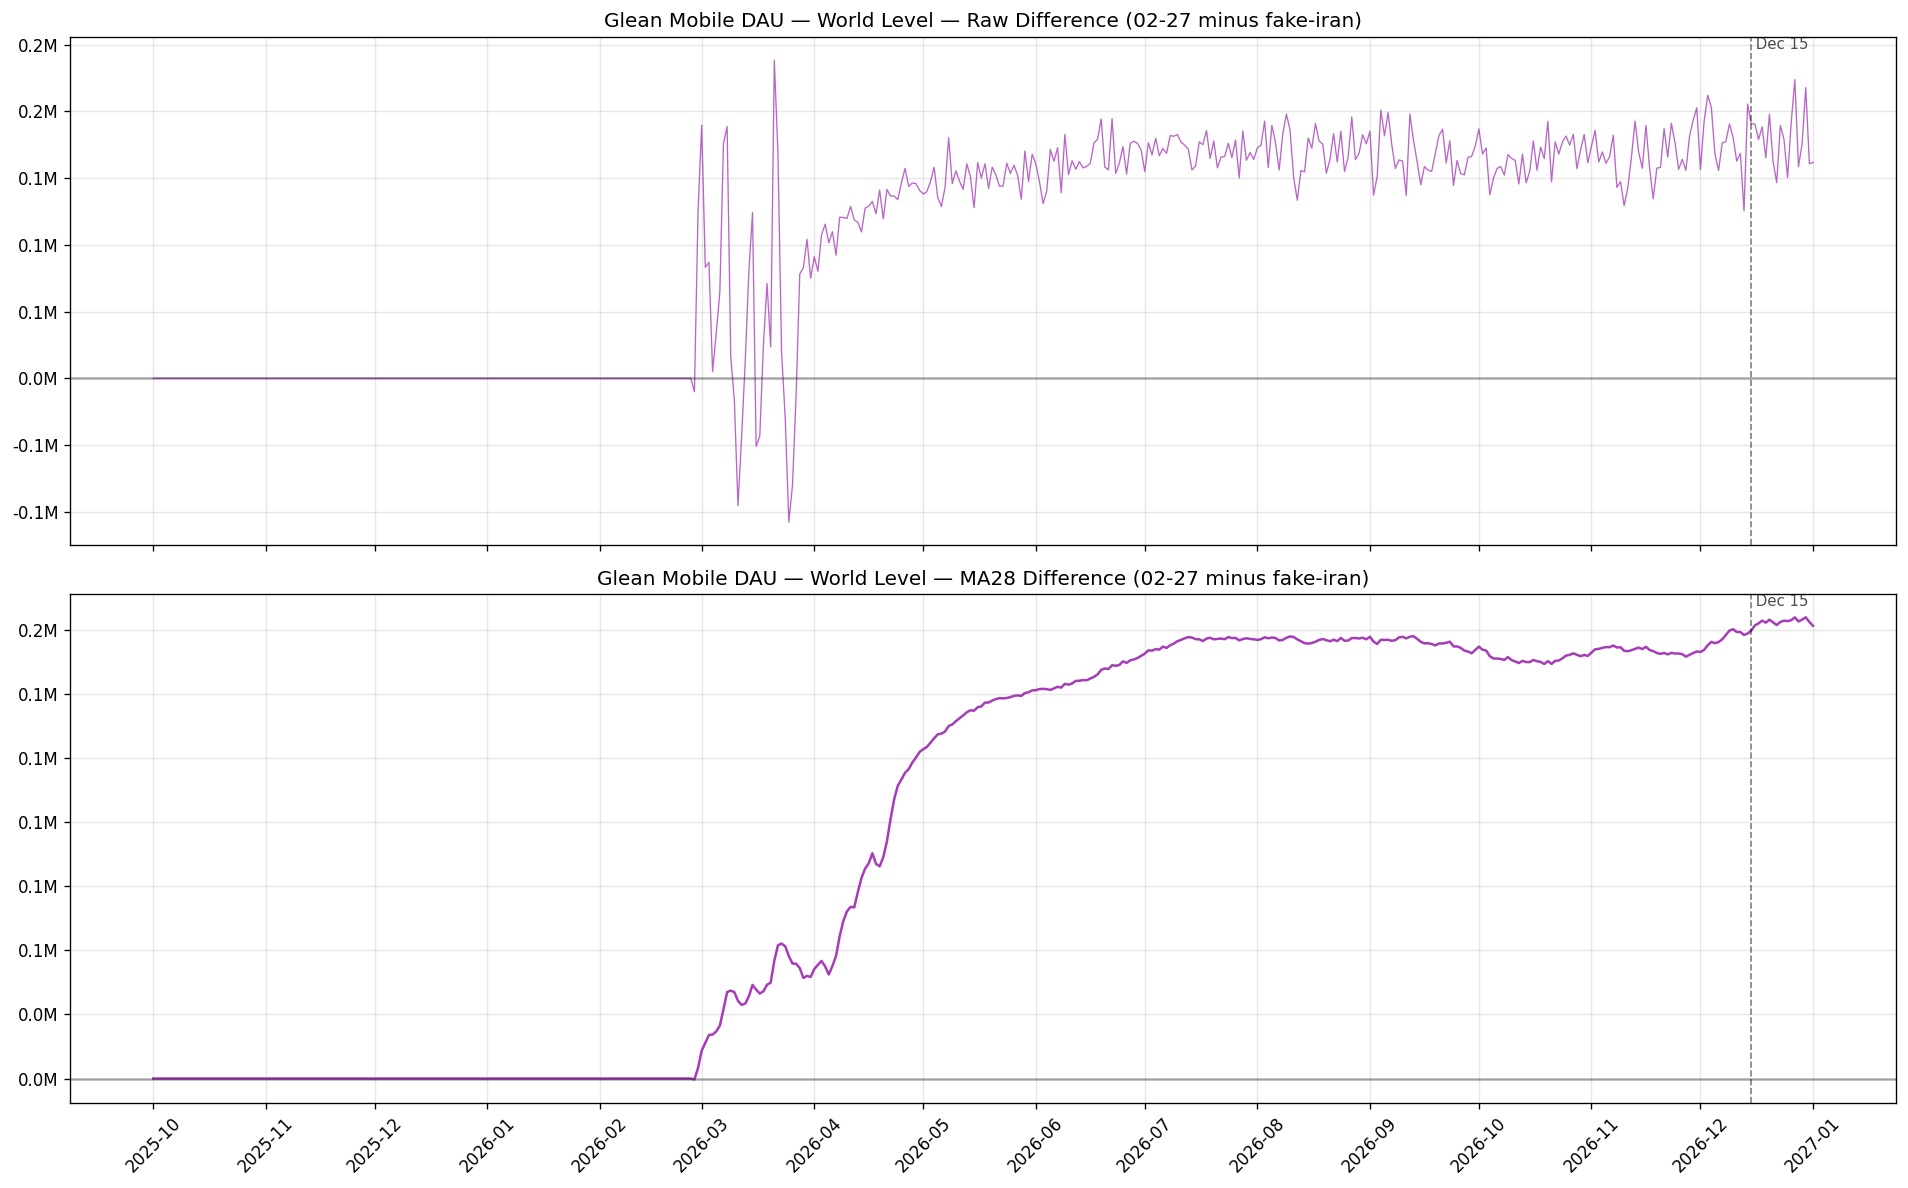

In [9]:
# [mobile-diff-0227-vs-fake]
plot_difference(mobile_0227, mobile_fake,
                title='Glean Mobile DAU — World Level')

In [10]:
# [pct-diff-at-accounting-date]
def pct_diff_at_date(base_df, compare_df, target_dt, label, use_ma=True):
    """Compute percent difference at a specific date.
    
    Returns (base_val, compare_val, diff, pct_diff).
    If use_ma, uses 28-day MA values.
    """
    if use_ma:
        base_df = add_ma28(base_df)
        compare_df = add_ma28(compare_df)
        col = 'dau_ma28'
    else:
        col = 'dau'
    
    base_val = base_df.loc[base_df['target_date'] == target_dt, col]
    compare_val = compare_df.loc[compare_df['target_date'] == target_dt, col]
    
    if len(base_val) == 0 or len(compare_val) == 0:
        return None
    
    base_val = base_val.iloc[0]
    compare_val = compare_val.iloc[0]
    diff = base_val - compare_val
    pct = (diff / base_val) * 100
    return base_val, compare_val, diff, pct


print('=== Dec 15 Accounting Date Comparison (28-day MA) ===')
print()

rows = []
for platform, base_df, fake_df, post_df in [
    ('Legacy Desktop', desktop_0227, desktop_fake, desktop_0323),
    ('Glean Mobile', mobile_0227, mobile_fake, mobile_0323),
]:
    result_fake = pct_diff_at_date(base_df, fake_df, ACCOUNTING_DATE, platform)
    result_post = pct_diff_at_date(base_df, post_df, ACCOUNTING_DATE, platform)
    
    if result_fake:
        base_val, fake_val, diff_fake, pct_fake = result_fake
        rows.append({
            'Platform': platform,
            '02-27 MA28': f'{base_val/1e6:.3f}M',
            'fake-iran MA28': f'{fake_val/1e6:.3f}M',
            '03-23 MA28': f'{result_post[1]/1e6:.3f}M' if result_post else 'N/A',
            '02-27 vs fake-iran': f'{diff_fake/1e6:+.3f}M ({pct_fake:+.2f}%)',
            '02-27 vs 03-23': f'{result_post[2]/1e6:+.3f}M ({result_post[3]:+.2f}%)' if result_post else 'N/A',
        })

summary_table = pd.DataFrame(rows)
print(summary_table.to_string(index=False))

=== Dec 15 Accounting Date Comparison (28-day MA) ===

      Platform 02-27 MA28 fake-iran MA28 03-23 MA28 02-27 vs fake-iran   02-27 vs 03-23
Legacy Desktop    49.467M        49.277M    49.260M   +0.190M (+0.38%) +0.207M (+0.42%)
  Glean Mobile    17.084M        16.909M    16.662M   +0.175M (+1.02%) +0.422M (+2.47%)


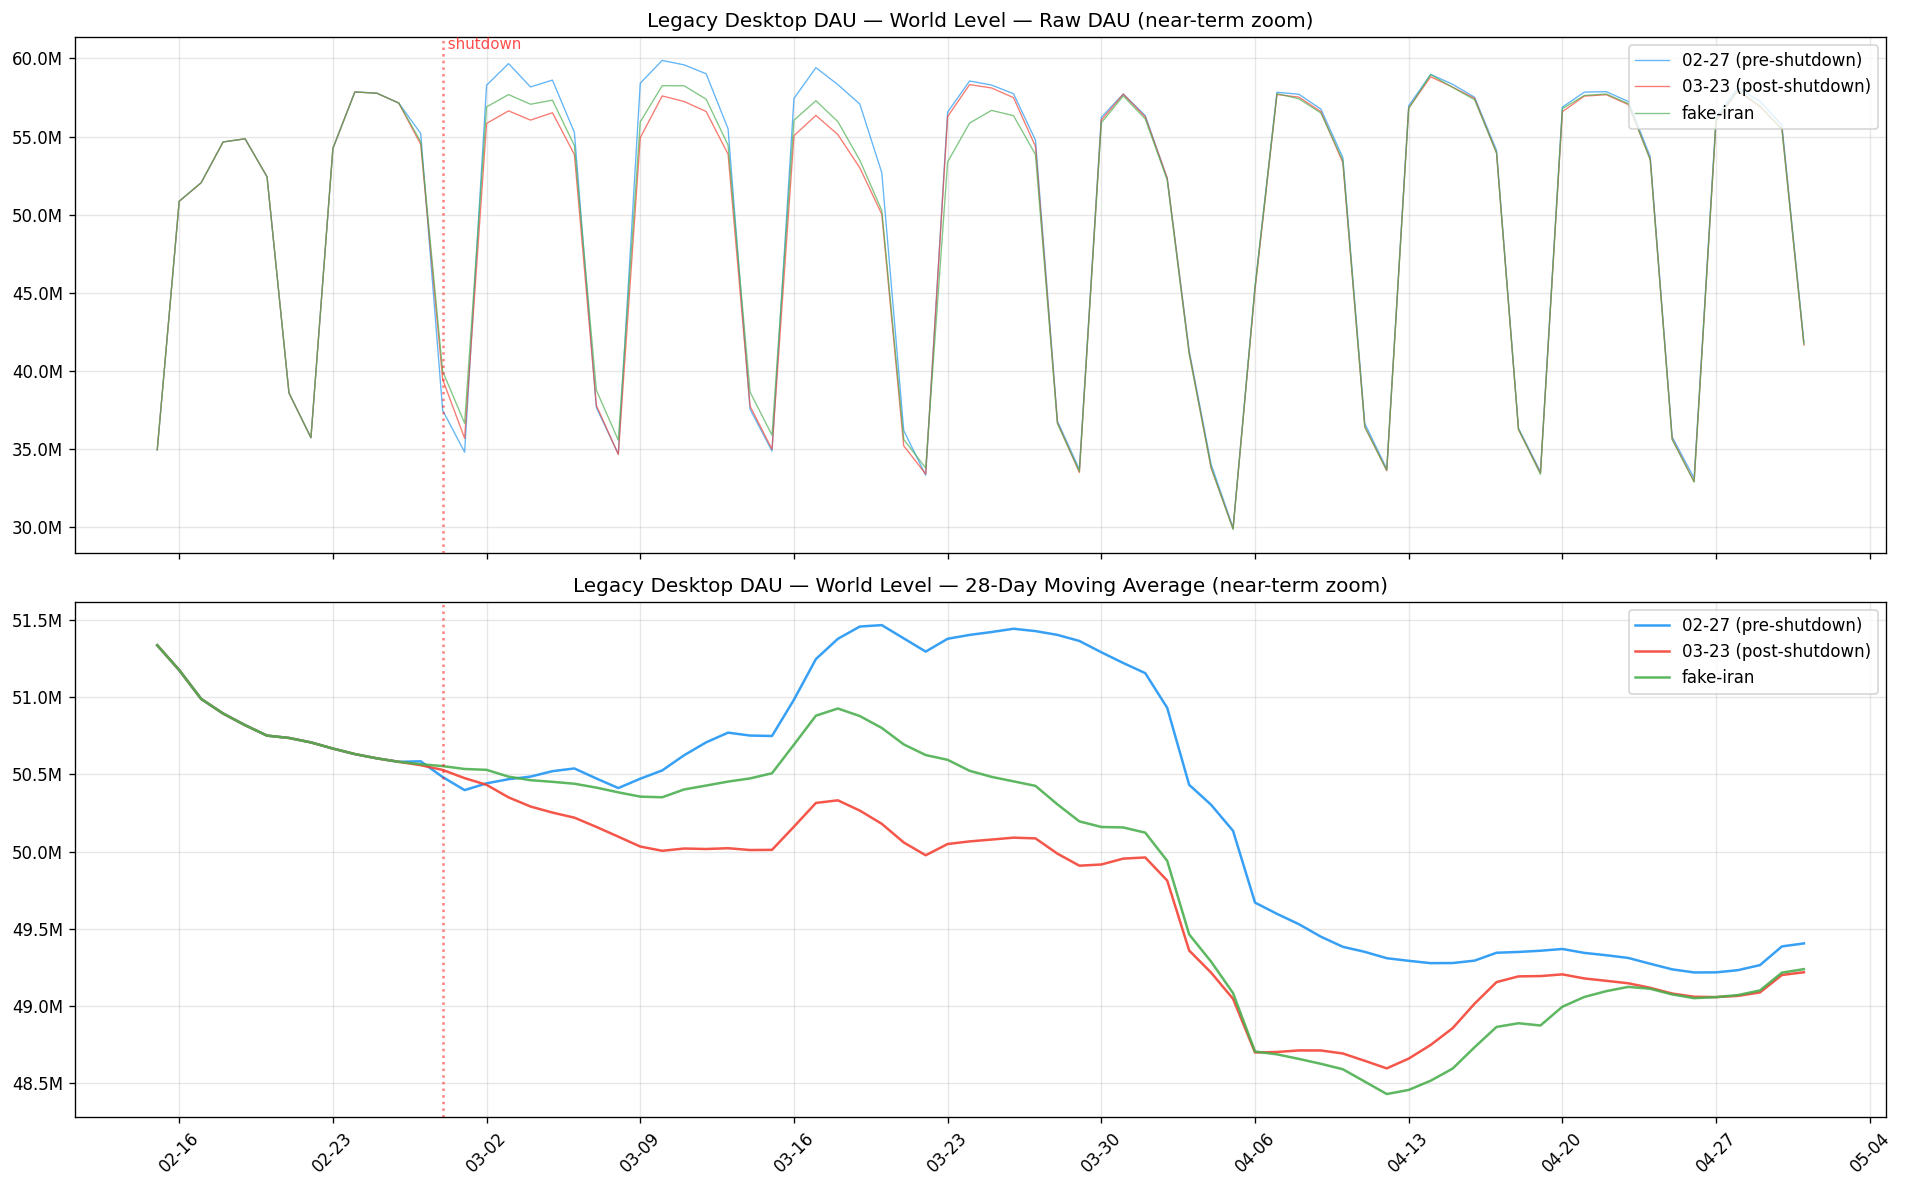

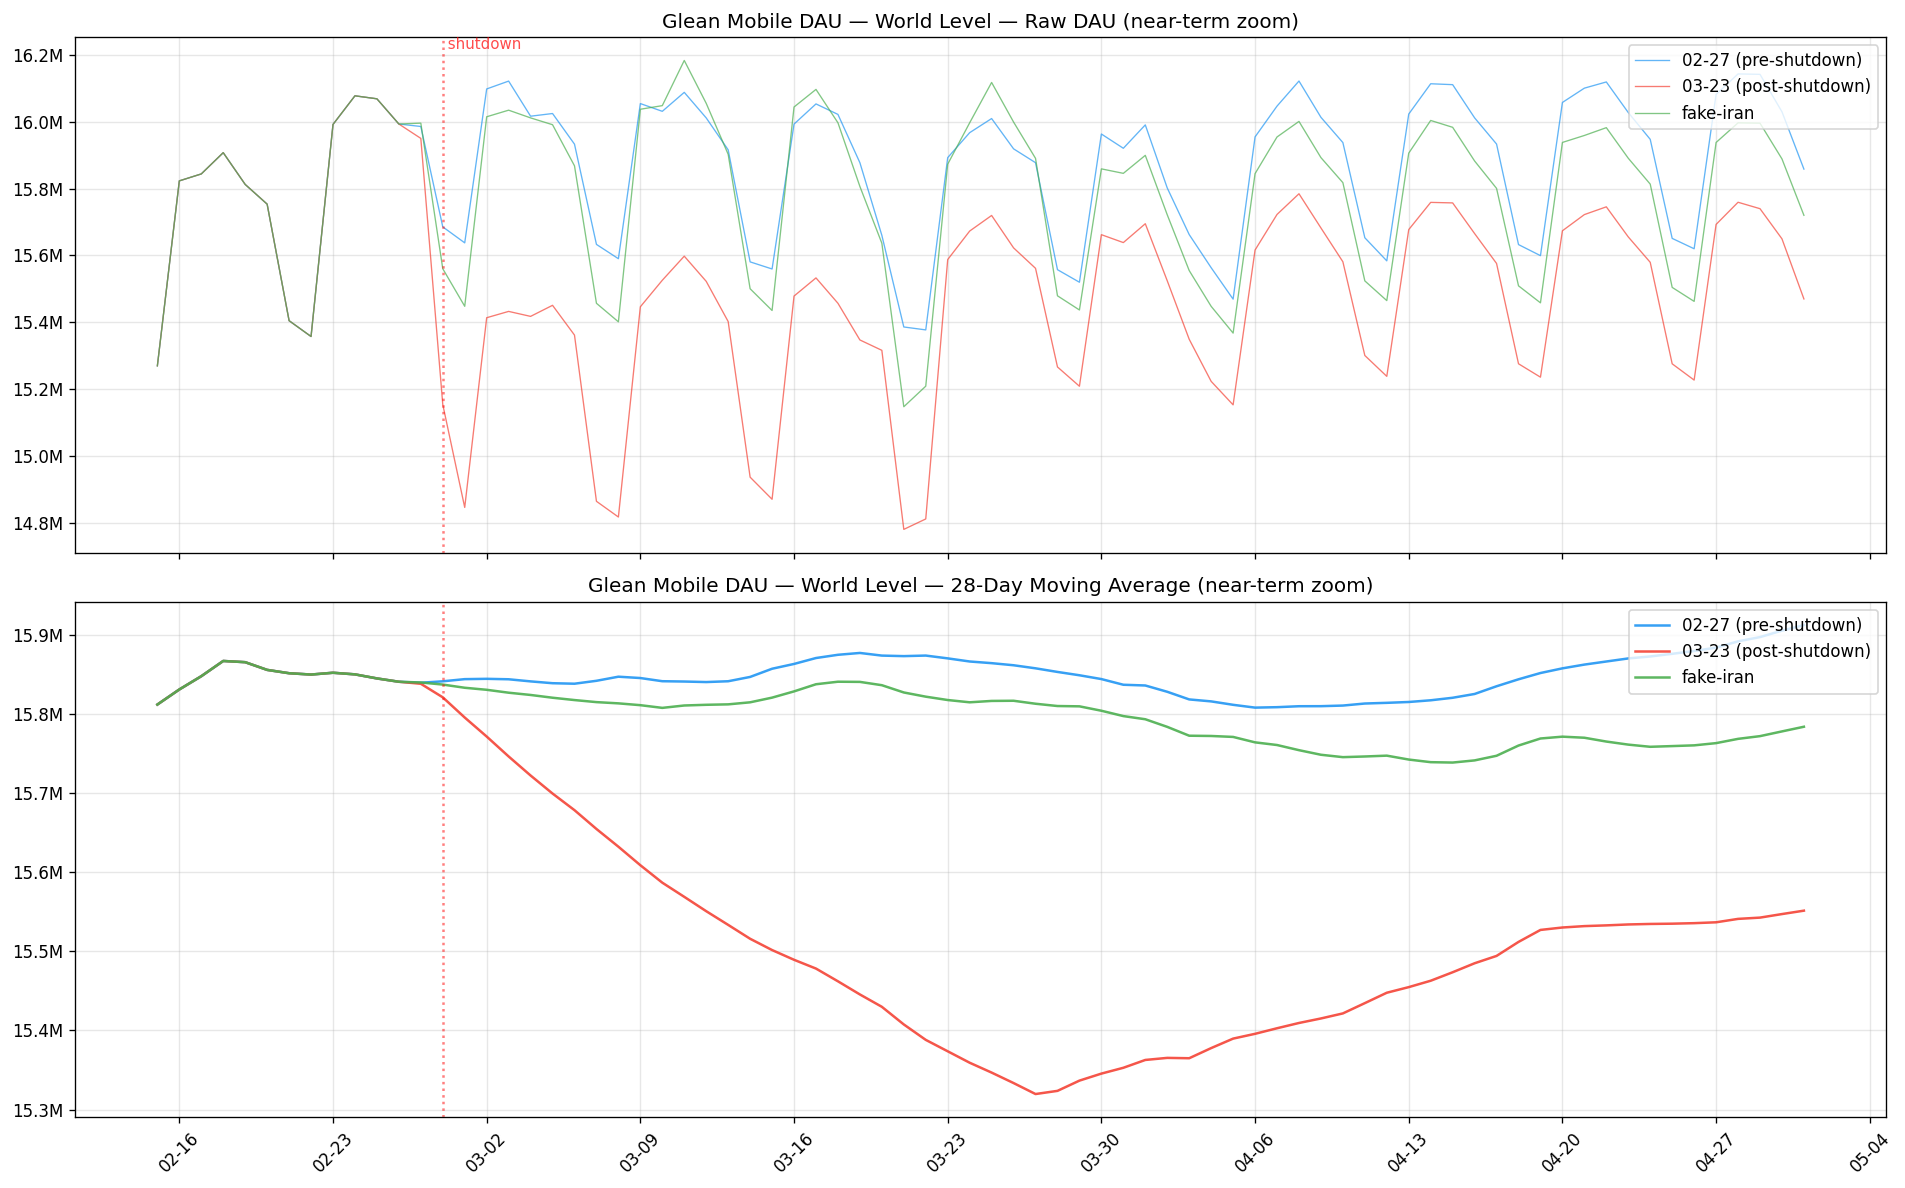

In [11]:
# [near-term-comparison]
# Zoom into March-April 2026 to see the near-term divergence between fake-iran and 03-23
NEAR_START = pd.Timestamp('2026-02-15')
NEAR_END = pd.Timestamp('2026-05-01')

def plot_near_term(datasets, title):
    """Zoomed plot of the near-term period where fake-iran vs 03-23 diverge."""
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    
    ax = axes[0]
    for label, df in datasets.items():
        df_plot = trim_to_range(df, NEAR_START, NEAR_END)
        ax.plot(df_plot['target_date'], df_plot['dau'],
                label=label, color=COLORS[label], alpha=0.7, linewidth=0.8)
    ax.set_title(f'{title} — Raw DAU (near-term zoom)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_millions))
    ax.legend(loc='upper right')
    # Mark the Iran shutdown date
    ax.axvline(pd.Timestamp('2026-02-28'), color='red', linestyle=':', alpha=0.5)
    ax.text(pd.Timestamp('2026-02-28'), ax.get_ylim()[1], ' shutdown', 
            va='top', ha='left', fontsize=9, color='red', alpha=0.7)
    
    ax = axes[1]
    for label, df in datasets.items():
        df_ma = add_ma28(df)
        df_plot = trim_to_range(df_ma, NEAR_START, NEAR_END)
        ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
                label=label, color=COLORS[label], alpha=0.9, linewidth=1.5)
    ax.set_title(f'{title} — 28-Day Moving Average (near-term zoom)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_millions))
    ax.legend(loc='upper right')
    ax.axvline(pd.Timestamp('2026-02-28'), color='red', linestyle=':', alpha=0.5)
    
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_near_term(
    {
        '02-27 (pre-shutdown)': desktop_0227,
        '03-23 (post-shutdown)': desktop_0323,
        'fake-iran': desktop_fake,
    },
    title='Legacy Desktop DAU — World Level'
)

plot_near_term(
    {
        '02-27 (pre-shutdown)': mobile_0227,
        '03-23 (post-shutdown)': mobile_0323,
        'fake-iran': mobile_fake,
    },
    title='Glean Mobile DAU — World Level'
)

In [12]:
# [monthly-summary-table]
# Monthly average DAU comparison for forecast period only

def monthly_forecast_summary(datasets, platform_label):
    """Build a monthly summary table of forecast DAU across the three runs."""
    rows = []
    for label, df in datasets.items():
        forecast_only = df[df['data_type'] == 'forecast'].copy()
        forecast_only['month'] = forecast_only['target_date'].dt.to_period('M')
        monthly = forecast_only.groupby('month')['dau'].mean()
        for month, val in monthly.items():
            rows.append({'Run': label, 'Month': str(month), 'Avg DAU': val})
    
    summary = pd.DataFrame(rows).pivot(index='Month', columns='Run', values='Avg DAU')
    # Reorder columns
    col_order = [c for c in ['02-27 (pre-shutdown)', 'fake-iran', '03-23 (post-shutdown)'] if c in summary.columns]
    summary = summary[col_order]
    
    # Add diff columns
    if '02-27 (pre-shutdown)' in summary.columns and 'fake-iran' in summary.columns:
        summary['02-27 vs fake (%)'] = (
            (summary['02-27 (pre-shutdown)'] - summary['fake-iran']) 
            / summary['02-27 (pre-shutdown)'] * 100
        ).round(2)
    
    # Format DAU as millions
    for col in col_order:
        summary[col] = summary[col].apply(lambda x: f'{x/1e6:.3f}M')
    
    print(f'\n=== {platform_label} — Monthly Average Forecast DAU ===')
    print(summary.to_string())
    return summary


desktop_monthly = monthly_forecast_summary(
    {'02-27 (pre-shutdown)': desktop_0227, '03-23 (post-shutdown)': desktop_0323, 'fake-iran': desktop_fake},
    'Legacy Desktop'
)

mobile_monthly = monthly_forecast_summary(
    {'02-27 (pre-shutdown)': mobile_0227, '03-23 (post-shutdown)': mobile_0323, 'fake-iran': mobile_fake},
    'Glean Mobile'
)


=== Legacy Desktop — Monthly Average Forecast DAU ===
Run     02-27 (pre-shutdown) fake-iran 03-23 (post-shutdown)  02-27 vs fake (%)
Month                                                                          
2026-02              46.341M      nanM                  nanM                NaN
2026-03              51.192M   45.927M               52.066M              10.29
2026-04              49.717M   49.548M               49.542M               0.34
2026-05              47.552M   47.398M               47.362M               0.32
2026-06              48.273M   48.119M               48.107M               0.32
2026-07              45.656M   45.486M               45.468M               0.37
2026-08              42.987M   42.815M               42.810M               0.40
2026-09              48.189M   48.017M               47.995M               0.36
2026-10              48.294M   48.144M               48.135M               0.31
2026-11              48.652M   48.491M               48.457M     